# 01: Classification

> Decision trees, random forests, and XGBoost for lateral spreading

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/01-dtree/01b-classification-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/01-dtree/01b-classification.ipynb)


### Install packages

In [ ]:
# Colab: install the packages this notebook uses
%pip install -q scikit-learn pandas xgboost shap

## Liquefaction

> Durante, M. G., & Rathje, E. M. (2021). An exploration of the use of machine learning to predict lateral spreading. Earthquake Spectra, 37(4), 2288-2314.

Soil liquefaction is a phenomenon that typically occurs in saturated loose sandy soils subjected to rapid loading conditions, such as earthquakes. The generation of excess pore water pressure is a direct consequence of the rapid loading, which can lead to a sudden reduction in the strength and stiffness of the soil. In the presence of gently sloping ground or near the free face of a slope, the occurrence of earthquake-induced liquefaction may generate lateral displacements, known as lateral spreading.

![liquefaction](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/liquefaction.png)

> Fig: (a) Observed liquefaction-related damage (data from NZGD, 2013), and (b) lateral spreading
horizontal displacement observed from optical image correlation (data from Rathje et al., 2017b) in the
Avon River area for the 2011 Christchurch earthquake

## Lateral spreading classification

Durante and Rathje (2021) classified sites that experienced more than 0.3 m displacement as lateral spreading. We now evaluate the four factors this dataset records: (i) GWD, the ground water depth (water closer to the surface means more chance of liquefaction), (ii) L, the distance to the nearest free face such as a river bank (closer means more spreading), (iii) Slope, the ground slope (steeper slopes drive more spreading), and (iv) PGA, the peak ground acceleration (the intensity of the shaking). The table also carries an elevation column, which we drop in the next section.

![Factors affecting liquefaction](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/liq-factors.png)

> Image credits: Durante and Rathje (2021).

### Explore data

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
CSV_URL = 'https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/RF_YN_Model3.csv'
LOCAL_CSV = 'RF_YN_Model3.csv'  # local copy, read when the download fails

try:
    df = pd.read_csv(CSV_URL)
except Exception:
    df = pd.read_csv(LOCAL_CSV)

In [4]:
df.head()

,Test ID,GWD (m),Elevation,L (km),Slope (%),PGA (g),Target
0,182,0.370809,0.909116,0.319117,5.465739,0.546270,0
1,15635,1.300896,1.123009,0.211770,0.905948,0.532398,0
2,8292,1.300896,0.847858,0.195947,0.849104,0.532398,0
3,15629,1.788212,2.044325,0.115795,0.451034,0.542307,0
4,183,1.637517,2.003797,0.137265,0.941866,0.545784,1


### Filtering for features

Remove any feature in the dataset that we don't want to include in the training process.

`Test ID` is an identifier, not a measurement. `Elevation` is dropped because 202 of the 7291
rows hold the float32 no-data marker -3.40282e+22 in that column instead of an elevation; the
cell below prints the count. A check for nulls does not find these rows, so the sentinel would
enter the model as a real value.

In [5]:
# 202 rows carry a sentinel instead of a measured elevation
print(f"Elevation rows holding -3.40282e+22: {(df['Elevation'] < -1e10).sum()} of {len(df)}")

df = df.drop(['Test ID', 'Elevation'], axis=1)
df.head()

Elevation rows holding -3.40282e+22: 202 of 7291


,GWD (m),L (km),Slope (%),PGA (g),Target
0,0.370809,0.319117,5.465739,0.546270,0
1,1.300896,0.211770,0.905948,0.532398,0
2,1.300896,0.195947,0.849104,0.532398,0
3,1.788212,0.115795,0.451034,0.542307,0
4,1.637517,0.137265,0.941866,0.545784,1


In [6]:
X = df.copy(deep=True)
y = df['Target']
y.head()

0    0
1    0
2    0
3    0
4    1
Name: Target, dtype: int64

### Training, testing and validation

When developing a machine learning model, it is common practice to divide the available data into three subsets - training, validation, and testing. This is done to properly assess model performance and generalizability.

The training set is used to fit the parameters of the model. The majority of the data, typically 60-80%, is allocated for training so that the model can learn the underlying patterns.

The validation set is used to tune any hyperparameters of the model and make architectural choices. For example, it helps decide the number of hidden layers and units in a neural network.

The test set provides an unbiased evaluation of the fully-trained model's performance. It is critical for getting an accurate estimate of how the model will work on new unseen data.

We split 80% for training, 10% for validation, and 10% for testing: 5832, 730, and 729 of the 7291 sites.

The splits should be made randomly while ensuring the class distribution is approximately balanced across all sets. No data from the validation or test sets should be used during training. This prevents overfitting and ensures the evaluation reflects real-world performance.

In [7]:
X

,GWD (m),L (km),Slope (%),PGA (g),Target
0,0.370809,0.319117,5.465739,0.546270,0
1,1.300896,0.211770,0.905948,0.532398,0
2,1.300896,0.195947,0.849104,0.532398,0
3,1.788212,0.115795,0.451034,0.542307,0
4,1.637517,0.137265,0.941866,0.545784,1
...,...,...,...,...,...
7286,1.631807,0.352863,0.839925,0.420179,0
7287,1.269804,0.584068,0.050562,0.416337,0
7288,1.500085,0.441609,0.360601,0.420179,0
7289,1.775998,0.353520,1.204065,0.420179,0


We are going to use the `train_test_split` function twice. The first call holds out 20% of the sites; the second call halves that remainder into a test set and a validation set. `stratify` keeps the 58/42 class balance in all three sets. We retain the target column for now, so we can check how good our prediction is.

**A caveat on this split.** The 7291 sites are neighbouring locations in one city, shaken by one earthquake, and 87 of them repeat an earlier row's features exactly. A random split therefore puts near-identical sites in both training and test, so every accuracy reported below is a within-region number and is optimistic about a new city or a new earthquake. The handout [Limitations of machine learning in geotechnical engineering](01-ml-limitations-handout.pdf) calls this spatial leakage and asks for a split at site or project level. This notebook fails that item on its checklist; read the accuracies as an upper bound.

In [8]:
X_train_target, X_val_test_target, y_train, y_val_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_test_target, X_val_target, y_test, y_val = train_test_split(
    X_val_test_target, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test)

print(f"train {len(X_train_target)}, test {len(X_test_target)}, validation {len(X_val_target)}")
print(f"spreading fraction: train {y_train.mean():.3f}, test {y_test.mean():.3f}, "
      f"validation {y_val.mean():.3f}")

train 5832, test 729, validation 730
spreading fraction: train 0.419, test 0.418, validation 0.419


In [9]:
X_val_target

,GWD (m),L (km),Slope (%),PGA (g),Target
4439,1.571790,1.647160,1.581851,0.395254,0
2995,2.117439,0.921559,1.227154,0.456954,1
4847,1.174054,0.830674,0.151452,0.425290,1
4504,1.230941,1.194841,0.456948,0.407299,0
5822,3.217474,0.129262,0.350147,0.443339,0
...,...,...,...,...,...
6347,1.869850,0.083701,0.125496,0.426110,1
40,1.962589,1.322103,0.235653,0.403432,0
3726,1.665907,0.478795,0.843798,0.487259,1
7148,2.015987,1.100716,1.060315,0.379102,0


In [10]:
X_train = X_train_target.drop(['Target'], axis=1)
X_test = X_test_target.drop(['Target'], axis=1)
X_val = X_val_target.drop(['Target'], axis=1)

In [11]:
X_test.head()

,GWD (m),L (km),Slope (%),PGA (g)
2271,1.818539,1.766037,0.355453,0.398704
125,2.118738,0.399891,0.183683,0.434206
1935,2.210156,1.468325,1.075267,0.397815
4987,2.442713,1.164817,0.566125,0.408304
4503,1.535410,2.125216,0.671203,0.385182


In [12]:
y_test.head()

2271    1
125     1
1935    0
4987    0
4503    0
Name: Target, dtype: int64

# Decision tree classifier

## Classification: Decision Trees

Classification is the task of predicting a categorical target variable based on input data. There are two main types of classification:

**Binary classification**: The target variable has two possible classes, often labeled 0 and 1. The goal is to predict which of the two classes an input belongs to. Examples include spam detection, disease diagnosis, etc.

**Multi-class classification**: The target variable has more than two possible discrete values or classes. The goal is to predict the specific class an input belongs to out of the multiple choices. Examples include image recognition, document categorization, etc.

A decision tree is a flowchart-like structure where each internal node represents a test on a feature (e.g., "is feature A > 5?"), each branch represents an outcome of the test, and each leaf node represents a class label. A decision tree is a supervised learning model used for both binary and multi-class classification. It works by recursively partitioning the input space into smaller subspaces based on the value of different predictor variables. The goal is to create leaf nodes that contain cases with similar values of the target variable.

The process of learning a decision tree involves selecting features and split points that best separate the classes, based on a criterion such as information gain or Gini impurity. It continues until a stopping criterion is met, like reaching a maximum depth or a minimum number of samples per leaf.

The structure of a decision tree consists of:

  *  __Root node__: This is the topmost node in the tree and contains the full dataset.
  *  __Internal nodes__: These represent points where the data is split based on values of predictor variables.
  *  __Branches__: These connect the internal nodesbased on possible values of predictors.
  *  __Leaf nodes__: These represent the final classifications or predictions.

Decision trees can handle both categorical and continuous predictors.

Some key advantages of decision trees are:

* __Interpretability__ - The tree structure and rules are easy to understand.
* __Non-parametric__ - No assumptions about data distribution.
* __Handles nonlinear relationships__ - By partitioning data recursively.
* __Handles categorical variables__ - No need for dummy coding.

![liquefaction decision tree](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/liq-dt.png)

### GINI Impurity

Gini impurity is used to evaluate how good a split is by calculating the impurity of the subsets resulting from the split. A lower Gini score means that the split is separating the classes well. It quantifies the disorder or uncertainty within a set of data.

The Gini impurity for a binary classification is calculated as:
$$Gini(t)=1−\sum(p_i)^2$$

where $p_i$​ is the probability of class $i$ in the set.

### Decision Tree splitting

A decision tree decides a split by selecting a feature and a value to divide the dataset into two or more homogenous subsets, according to a certain criterion. The ultimate goal is to find the splits that produce the purest subsets, meaning that each subset ideally contains data points from only one class. Here's how it works:

  - **Selection of Criteria**: The method used to decide a split depends on the criterion being used. Common criteria for classification tasks include Gini Impurity, Information Gain, and Chi-Squared. For regression tasks, variance reduction is often used.

  - **Evaluate Each Feature and Potential Split**: For each feature in the dataset, the algorithm calculates the criterion's value for every potential split point. Split points can be the actual values of a continuous feature or different categories of a categorical feature.

  - **Choose the Best Split**: The algorithm selects the feature and split point that produces the subsets with the highest purity according to the chosen criterion. For example:
        In the case of Gini Impurity, the best split minimizes the impurity.
        In the case of Information Gain, the best split maximizes the gain.

  - **Create Subsets**: Once the best split has been identified, the dataset is divided into subsets according to the chosen feature and split point.

  - **Repeat**: Steps 1-4 are repeated recursively on each of the subsets until a stopping criterion is met, such as reaching a certain tree depth or the subsets being pure enough.

#### Example Using Gini Impurity

  - For each feature, consider all possible values for splitting.
  - A split sends $n_L$ of the node's $n$ samples left and $n_R$ right. Score it by the weighted
    impurity of the two children:
    $$G_{\text{split}} = \frac{n_L}{n} Gini(L) + \frac{n_R}{n} Gini(R)$$
  - Choose the split with the lowest $G_{\text{split}}$.
  - Divide the dataset accordingly and continue the process.

For example, the root of the depth-3 tree plotted below holds all 5832 training sites, 2444 of
them spreading, so $Gini(\text{root}) = 1 - 0.581^2 - 0.419^2 = 0.487$. The chosen split is
`PGA (g)` $\le$ 0.421 g. It sends 2188 sites left, of which 640 spread
($Gini = 1 - 0.707^2 - 0.293^2 = 0.414$), and 3644 right, of which 1804 spread
($Gini = 0.500$). The weighted child impurity is
$\frac{2188}{5832}(0.414) + \frac{3644}{5832}(0.500) = 0.468$, below the root's 0.487, so the
split is an improvement. No other feature and threshold does better at this node.

#### Entropy and Information Gain

Entropy measures the same disorder on a logarithmic scale:
$$H(t) = -\sum_i p_i \log_2 p_i$$

Information gain is the drop in entropy the split produces:
$$IG = H(\text{parent}) - \frac{n_L}{n} H(L) - \frac{n_R}{n} H(R)$$

Gini and entropy rank splits almost identically. `DecisionTreeClassifier` takes either through
its `criterion` argument, and the grid search later in this notebook tries both.

In the context of decision trees, the splitting process is essential as it helps the model generalize the pattern from the training data, enabling accurate predictions or classifications for unseen data. It's the core step in building the tree, and different algorithms might have variations in the splitting procedure.

## Decision tree with SciKit Learn

Scikit-learn, often referred to as sklearn, is one of the most popular libraries for machine learning in Python

In [13]:
from sklearn import tree
from sklearn.metrics import accuracy_score

In [14]:
clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [15]:
print('Training score: %.2f%%' %(clf.score(X_train, y_train) * 100))
print('Validation score: %.2f%%' %(clf.score(X_val, y_val) * 100))
print('Testing score: %.2f%%' %(clf.score(X_test, y_test) * 100))

Training score: 68.14%
Validation score: 69.04%
Testing score: 68.31%


In [16]:
accuracy_score(y_test, clf.predict(X_test))

0.6831275720164609

#### Prediction

In [17]:
clf.predict(X_test)[4]

np.int64(0)

### Visualizing a decision tree

/var/folders/w8/xz590jyd7r36zmxcspgzj3z40000gn/T/ipykernel_84133/3738266525.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


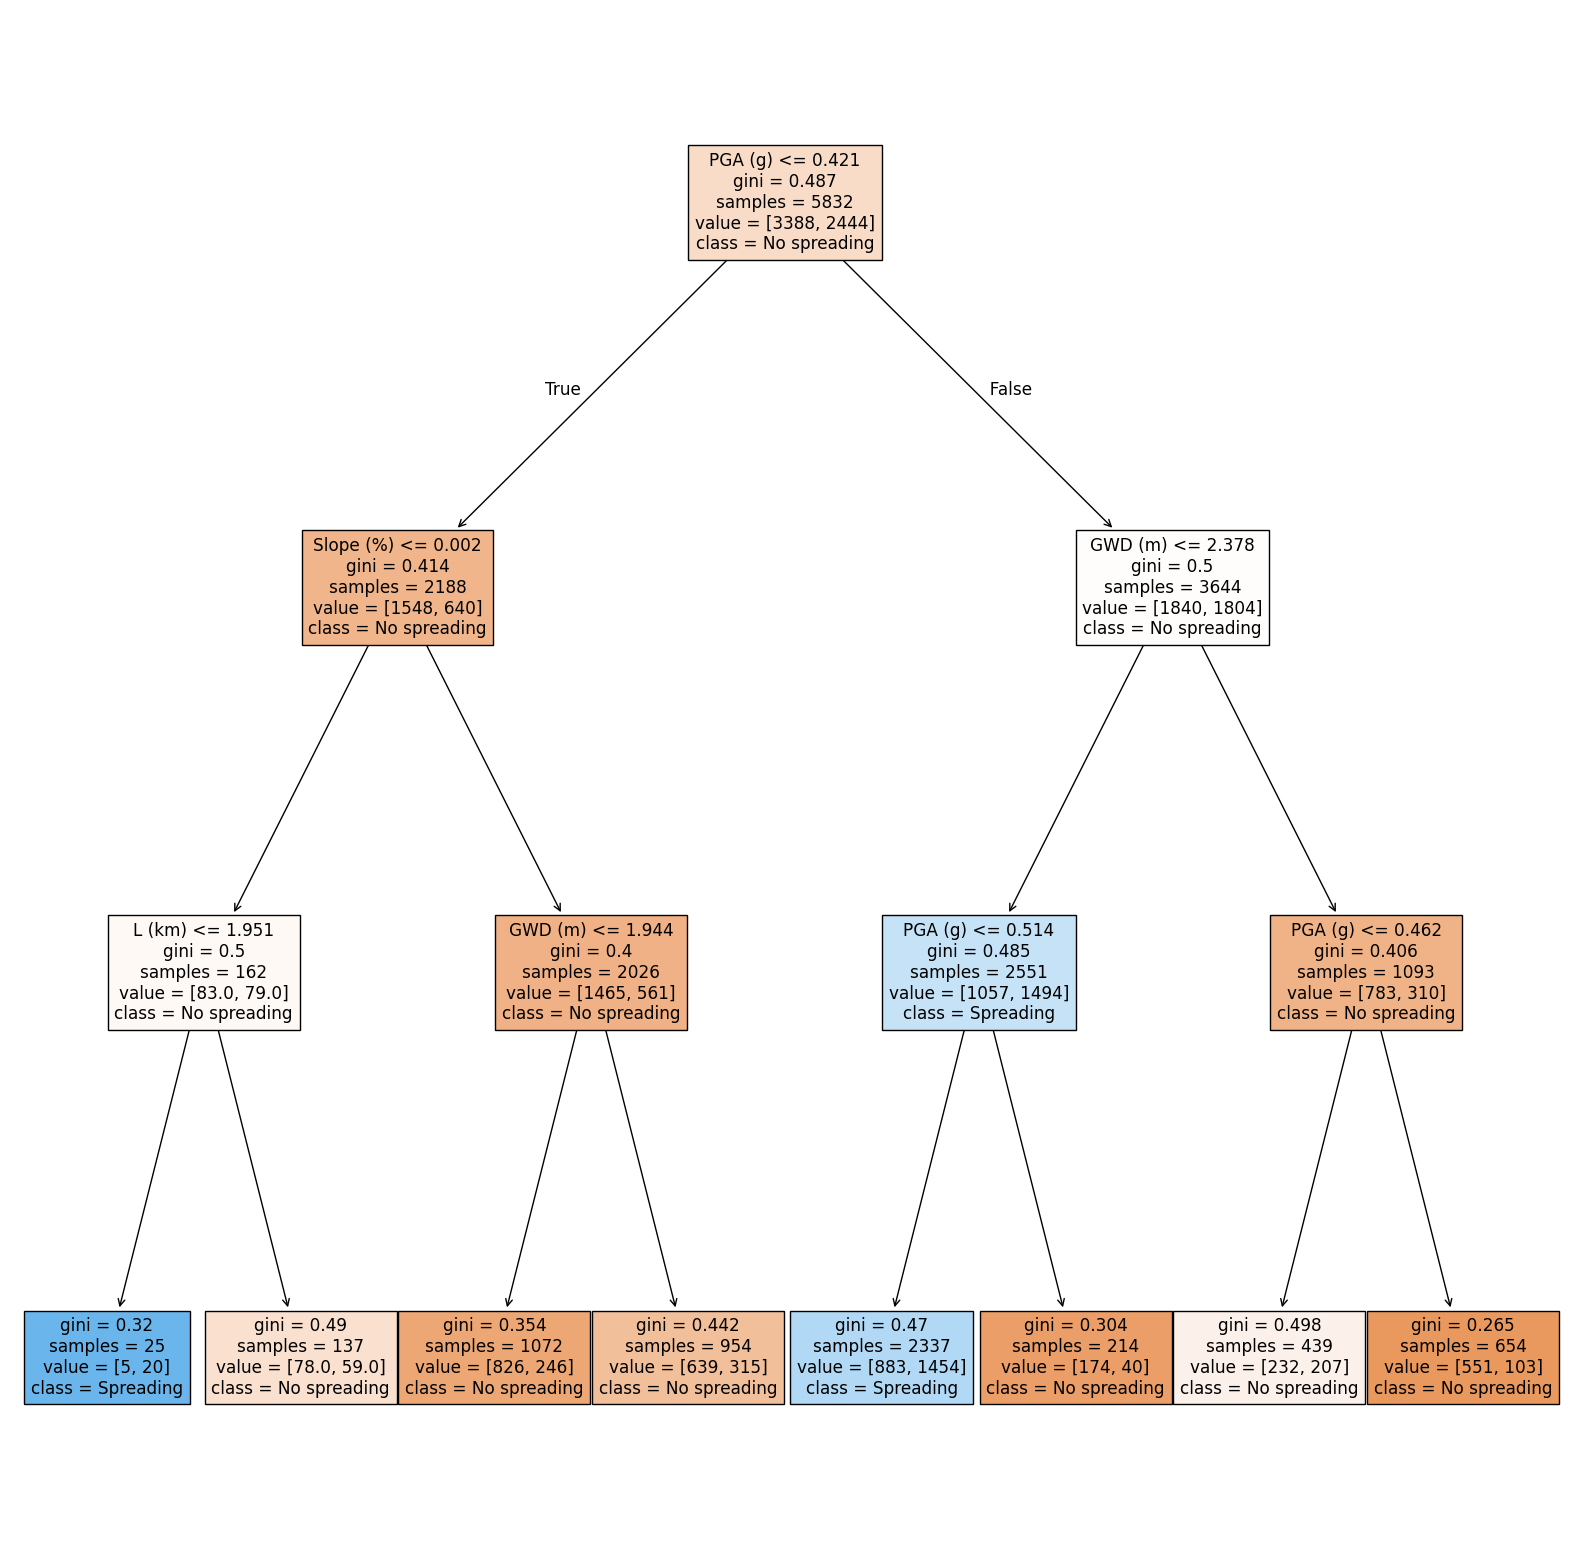

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(clf,
               feature_names =['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)'],
               class_names=['No spreading', 'Spreading'],
               filled = True)
fig.show()

### Update model

We increase the `max_depth` to 7 so we have a better fit.

> 💡 Try varying the `max_depth` from 5 - 9.

In [19]:
clf = tree.DecisionTreeClassifier(max_depth=7, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [20]:
print('Training score: %.2f%%' %(clf.score(X_train, y_train) * 100))
print('Validation score: %.2f%%' %(clf.score(X_val, y_val) * 100))
print('Testing score: %.2f%%' %(clf.score(X_test, y_test) * 100))

Training score: 77.16%
Validation score: 74.52%
Testing score: 76.13%


### Analyzing Model Performance vs Tree Depth

Let's systematically analyze how the decision tree's performance changes with different `max_depth` values. This helps us understand the trade-off between model complexity and generalization.

Validation accuracy here keeps climbing well past depth 7 while the train-validation gap
widens. That is a symptom of the split, not of a genuinely better model: neighbouring sites
sit on both sides of a random split, so a deep tree can memorise a training neighbour and
still score well on validation. The depth-7 tree used above is the point of diminishing
returns and is small enough to read.

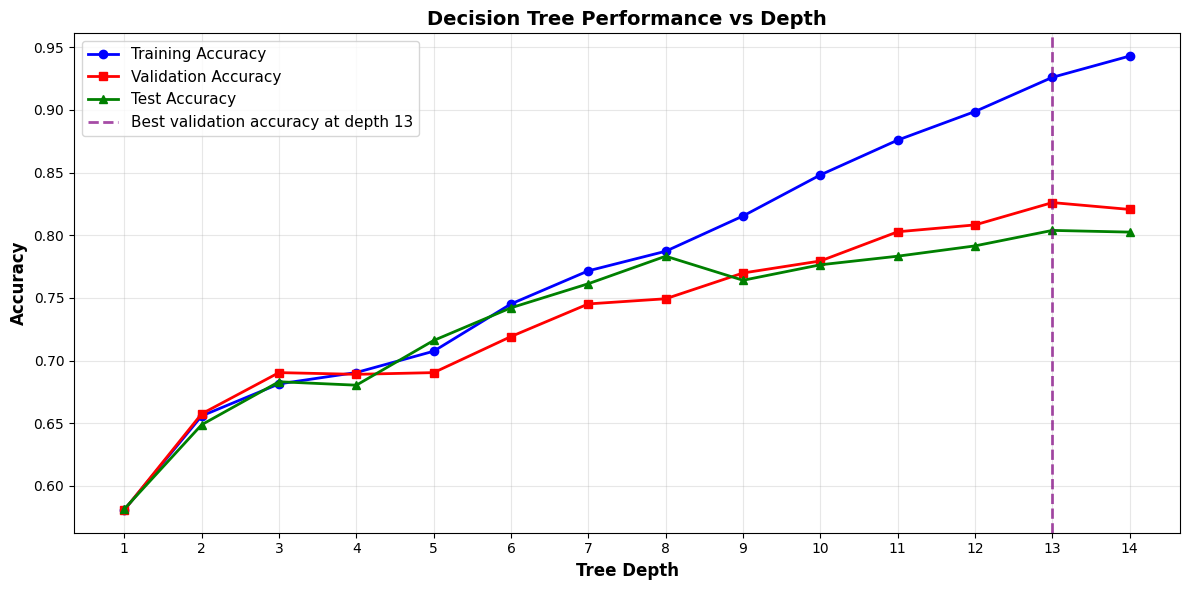

Highest validation accuracy at depth: 13

Performance at that depth:
  Training Accuracy:   0.9259
  Validation Accuracy: 0.8260
  Test Accuracy:       0.8038

Overfitting Analysis:
  Depth  3: Train-Val gap = -0.0090 (Low overfitting)
  Depth  7: Train-Val gap = 0.0264 (Low overfitting)
  Depth 10: Train-Val gap = 0.0686 (Moderate)
  Depth 14: Train-Val gap = 0.1224 (High overfitting)


In [21]:
# Analyze accuracy vs depth
import numpy as np
import matplotlib.pyplot as plt

depths = range(1, 15)
train_scores = []
val_scores = []
test_scores = []

for depth in depths:
    clf_depth = tree.DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_depth.fit(X_train, y_train)
    
    train_scores.append(clf_depth.score(X_train, y_train))
    val_scores.append(clf_depth.score(X_val, y_val))
    test_scores.append(clf_depth.score(X_test, y_test))

# Plot accuracy vs depth
plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(depths, val_scores, 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.plot(depths, test_scores, 'g-^', label='Test Accuracy', linewidth=2, markersize=6)
plt.xlabel('Tree Depth', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Decision Tree Performance vs Depth', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(depths)

# Depth with the highest validation accuracy
optimal_depth = list(depths)[int(np.argmax(val_scores))]
plt.axvline(x=optimal_depth, color='purple', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Best validation accuracy at depth {optimal_depth}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Highest validation accuracy at depth: {optimal_depth}")
print(f"\nPerformance at that depth:")
print(f"  Training Accuracy:   {train_scores[optimal_depth-1]:.4f}")
print(f"  Validation Accuracy: {val_scores[optimal_depth-1]:.4f}")
print(f"  Test Accuracy:       {test_scores[optimal_depth-1]:.4f}")

# Show overfitting analysis
print(f"\nOverfitting Analysis:")
for depth in [3, 7, 10, 14]:
    gap = train_scores[depth-1] - val_scores[depth-1]
    print(f"  Depth {depth:2d}: Train-Val gap = {gap:.4f} ({'High overfitting' if gap > 0.1 else 'Moderate' if gap > 0.05 else 'Low overfitting'})")

## Metrics

A confusion matrix is commonly used to evaluate the performance of a machine learning classification model. It is an N x N matrix that summarizes how well the model classifies examples into N distinct classes.

The confusion matrix compares the actual target values to the predicted values. It shows the number of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) for each class. A higher count of TP and TN indicates better model performance, while more FP and FN points mean the model is making errors.

Key evaluation metrics derived from the confusion matrix are accuracy, recall (or true positive rate), and precision. Accuracy measures the overall percentage of correct classifications, treating false positives and false negatives equally.

Recall calculates the fraction of positive cases that are correctly classified as positive. It looks across the rows of the confusion matrix. Precision looks down the columns, measuring the fraction of positive predictions that are true positives. High precision means few false positives.

For binary classification, the formulas for these metrics are:

Accuracy = $(TP + TN)/(TP + TN + FP + FN)$

Recall = $TP/(TP + FN)$ = TP/(all positive data)

Precision = $TP/(TP + FP)$ = TP/(all positive predictions)

The confusion matrix and these metrics provide a quantitative assessment of model performance on a classification problem. They highlight the types of errors and allow targeted improvement.

**Precision**:
- Definition: Ratio of correctly predicted positive observations to the total predicted positives.
- Formula: 
  $$ \text{Precision} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Positive}} $$
- Interpretation: Of all instances labeled as positive, how many were actually positive?

**Recall (Sensitivity)**:
- Definition: Ratio of correctly predicted positive observations to all actual positives.
- Formula: 
  $$ \text{Recall} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}} $$
- Interpretation: Of all actual positive instances, how many were correctly labeled?

**Trade-off**:
- Precision and recall often have a trade-off.
- F1 score combines both:
  $$ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

**Decision Trees and Precision-Recall**:
- Decision trees use feature thresholds to make decisions.
- Adjusting decision thresholds can influence precision and recall.
- Precision-Recall curves visualize the trade-off.

> Note: Consider both precision and recall for imbalanced datasets or when false positives and negatives have different implications.


Researchers commonly use receiver operating characteristic (ROC) curves to evaluate the performance of machine learning classification models. A ROC curve plots the true positive rate (TPR) against the false positive rate (FPR) for different classification probability thresholds. The TPR, also called recall, represents the percentage of positive cases correctly classified. The FPR represents the percentage of negative cases incorrectly classified as positive.

The FPR represents the fraction of the negative points that are incorrectly classified as positive (FPR = FP/(FP + TN) = FP/(all negative data)). An ideal classifier will have a ROC curve that passes through the top left corner, with a TPR of 1 and FPR of 0. A random classifier will have a ROC curve along the diagonal line where TPR equals FPR. Less accurate models have curves closer to the diagonal, while more accurate models have curves further up and left.

The area under the ROC curve (AUC) quantifies the model's performance. Larger AUC values indicate better classification, with a maximum of 1. AUC values near 0.5 imply performance equal to a random classifier.

Although designed for binary classification, ROC analysis can be extended to multi-class problems using a one-vs-rest approach. This involves creating a binary classifier for each class against the rest. The per-class curves are then combined by macro averaging (an unweighted mean over classes), micro averaging (pooling every prediction into one curve), or a mean weighted by class size.

### Plot metrics

### Confusion Matrix

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, normalize=False):

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / len(y_true)
        cm = np.round(cm, decimals=3)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap=plt.cm.Blues)

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['No','Yes'])
    ax.set_yticklabels(['No','Yes'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    ax.set_title('Confusion Matrix')
    fig.tight_layout()
    plt.show()

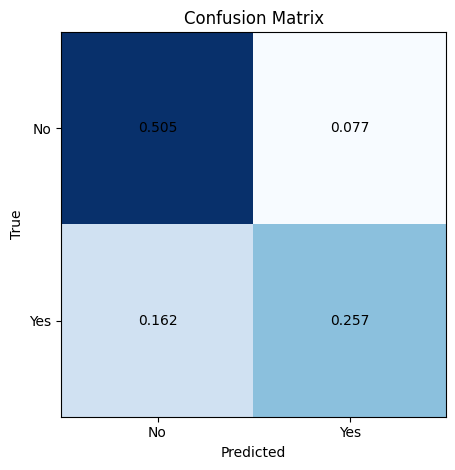

In [23]:
# make prediction on test set
y_pred = clf.predict(X_test)
# plot confusion matrix for test set
plot_confusion_matrix(y_test, y_pred, normalize=True)

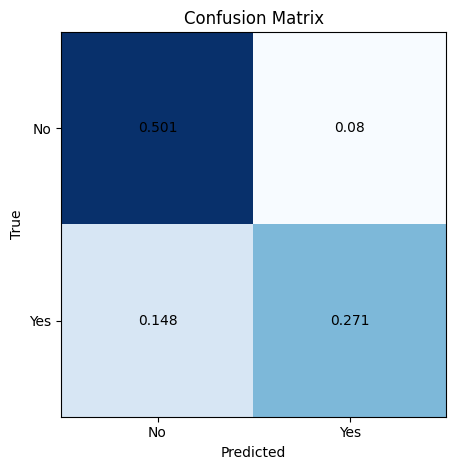

In [24]:
# make prediction on training set
y_pred_train = clf.predict(X_train)
# plot confusion matrix for training set
plot_confusion_matrix(y_train, y_pred_train, normalize = True)

### ROC

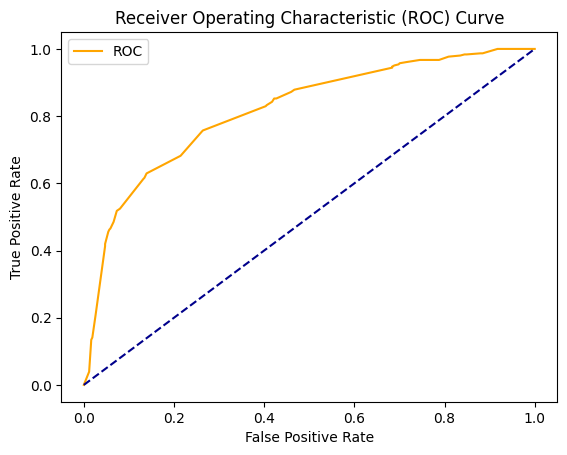

In [25]:
from sklearn.metrics import cohen_kappa_score, roc_curve, roc_auc_score, accuracy_score, classification_report, make_scorer

def plot_roc_cur(fper, tper):
    plt.plot(fper, tper, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

probs = clf.predict_proba(X_test)[:, 1]
fper, tper, thresholds = roc_curve(y_test, probs)
plot_roc_cur(fper, tper)

#### Precision recall curve

A precision-recall curve (PR curve) is another common technique used to evaluate the performance of classification models, alongside ROC curves. The PR curve plots precision vs. recall at different thresholds.

Precision measures the fraction of positive predictions that are true positives, while recall (same as true positive rate) measures the fraction of actual positives correctly predicted as positive.

A PR curve shows the tradeoff between precision and recall. High recall means detecting most of the positive cases, but potentially more false positives. High precision means positive predictions are more accurate, but some positives may be missed.

The curve is generated by varying the classification threshold and plotting precision and recall at each threshold. A perfect classifier will have a horizontal line at precision = 1. Random guessing gives a horizontal line at precision equal to the positive class fraction, 0.42 for this dataset. The diagonal is the baseline for the ROC curve, not for this one.

The area under the PR curve, called average precision or AUPRC, summarizes the overall performance. Higher values indicate better classification. Do not call it AUC: that name is taken by the area under the ROC curve above, and the two numbers are different.

__Advantages of PR curves__:

 - Better visualization of performance for imbalanced classes. ROC curves can hide poor performance on the minority class.
 - Directly shows precision-recall tradeoff important for many applications.
 - Can be more useful than ROC curves when the positive class is more important.

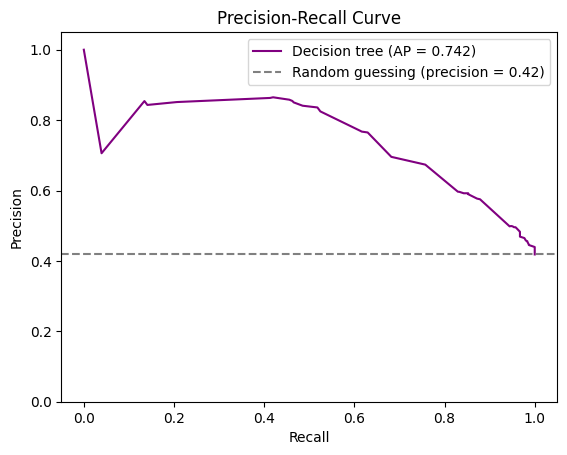

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# score the test set with the decision tree
y_score = clf.predict_proba(X_test)[:, 1]

#calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

#create precision recall curve
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple', label=f'Decision tree (AP = {ap:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--',
           label=f'Random guessing (precision = {baseline:.2f})')

#add axis labels to plot
ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')
ax.set_ylim(0, 1.05)
ax.legend()

#display plot
plt.show()

### Summary of decision trees


Pros and Cons
- Pros: Simple to understand and visualize, able to handle categorical and numerical data.
- Cons: Prone to overfitting, especially when the tree is deep, leading to poor generalization to unseen data. A small change in the data can lead to a very different tree.

# Random Forest

A random forest is an ensemble method that builds multiple decision trees and combines their predictions. Here's how it works:

**Bootstrapping**: For each tree in the forest, a subset of the training data is sampled with replacement. This helps in reducing overfitting by ensuring that each tree in the forest sees a slightly different subset of the data.

**Random Feature Selection**: When splitting a node, a random subset of features is considered. This further decorrelates the trees and improves generalization.

**Voting or Averaging**: `sklearn.ensemble.RandomForestClassifier` averages the class probabilities predicted by the individual trees and returns the class with the largest average. Majority voting over the trees' hard labels is the textbook variant of the same idea, and it usually gives the same answer. For regression, the mean prediction is used.

**Pros and Cons**

- Pros: Reduced risk of overfitting compared to a single decision tree, often gives better predictive performance, handles missing data well.
- Cons: More computationally expensive, harder to interpret because of the ensemble nature.

**Difference Between Random Forest and Decision Tree**

- Composition: A decision tree is a single tree, while a random forest is a collection of decision trees.
- Overfitting: Random forests are generally less prone to overfitting compared to individual decision trees.
- Prediction: A decision tree makes a prediction based on a single path through the tree, while a random forest averages or takes a vote from multiple trees.
- Computation and Interpretation: Random forests are more computationally intensive and less interpretable than individual decision trees.


In the context of SciML, both decision trees and random forests can be powerful tools. Decision trees are often used for their interpretability and simplicity, while random forests are employed for their robustness and improved predictive accuracy. Understanding the underlying mechanics and differences between these methods can help researchers and practitioners make informed choices for their specific applications.

![Decision tree vs Random Forest](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/decision-tree-rf.png)

### Automatic Hyperparameter tuning

Like we varied `max_depth`, there are other hyperparameters than can be tuned to improve performance.

[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

Cohen's kappa score measures the agreement between two raters/classifiers while taking into account the agreement expected by chance.

The $\kappa$ score is calculated as:

$$\kappa = (p_o - p_e) / (1 - p_e)$$

Where:

    $p_o$ is the observed agreement between raters (accuracy)
    $p_e$ is the expected agreement by chance

Values range from -1 to 1, where 0 is chance level agreement and 1 is perfect agreement.

In machine learning, kappa can be used as an evaluation metric for classification models. It gives a more robust measure of performance than simple accuracy, by accounting for random chance.

`GridSearchCV` is a tool in sklearn to perform hyperparameter tuning. It tries out all combinations of specified hyperparameters, fits a model on each, and returns the best performing configuration based on a scoring metric (like kappa).

So in this approach, we are using `GridSearchCV` to optimize the hyperparameters of a Random Forest Classifier to maximize the kappa score, rather than just overall accuracy.

The goal is to tune hyperparameters like `max_depth`, `n_estimators` etc. to find the values that result in the best kappa score, indicating the model's predictions have the strongest agreement with the true labels after accounting for chance.

This often results in a model that generalizes better than just optimizing for accuracy. The final model can then be evaluated with cross-validation to estimate real-world performance.
The grid below is deliberately small: 3 depths x 2 forest sizes x 2 feature rules x 2 criteria
= 24 combinations, scored with 3-fold cross-validation, which is 72 fits and runs in seconds.
A wider grid (`max_depth` 2 to 9, `n_estimators` up to 1000, `cv=10`) is 1600 fits and takes
minutes to an hour; widen it once you have the small version working.

### K-Fold Cross-Validation (CV)

K-fold cross-validation is a popular resampling procedure used to evaluate a machine learning model's performance.

#### How K-Fold CV Works:
1. **Partitioning:** The original training data set is randomly partitioned into $ k $ equal-sized subsets or "folds."
2. **Training and Validation:** Of the $ k $ folds, $ (k-1) $ are used for training, and one is used for validation. This is repeated $ k $ times.
3. **Evaluation:** You'll train the model on $ (k-1) $ folds and validate it on the remaining fold, recording the error metric.
4. **Aggregation:** Average the recorded error metrics to obtain a single value that represents the model's performance.

#### Benefits of K-Fold CV
- **Bias-Variance Tradeoff:** Good bias-variance tradeoff.
- **Utilizing All Data:** Beneficial when dataset size is limited.
- **Reduction in Overfitting:** Helps in detecting overfitting.

#### Drawbacks
- **Computationally Expensive:** Requires training and validating the model $ k $ times.
- **Randomness in Partitions:** Performance estimate can be sensitive to how the data is divided.

In [27]:
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import cohen_kappa_score, roc_curve, roc_auc_score, accuracy_score, classification_report, make_scorer
from sklearn.ensemble import RandomForestClassifier

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Create and fit the model
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=9,           # same as your XGBoost
    random_state=42        # for reproducibility
)

rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

In [29]:
#define function to find best parameter combination based on Cohen's kappa coefficient
def rfr_model(X, y):
# Perform Grid-Search
    kappa_scorer = make_scorer(cohen_kappa_score)
    gsc = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid={
            'max_depth': (5, 7, 9),
            'n_estimators': (100, 300),
            'max_features': ('sqrt', 'log2'),
            'criterion': ('gini', 'entropy'),
        },
        cv=3, verbose=0, n_jobs=-1, scoring=kappa_scorer)

    grid_result = gsc.fit(X, y)
    best_params = grid_result.best_params_

    rfr = RandomForestClassifier(max_depth=best_params["max_depth"],
                                 n_estimators=best_params["n_estimators"],
                                 max_features=best_params["max_features"], 
                                 criterion = best_params["criterion"],
                                 random_state=42)
    # Perform K-Fold CV
    scores = cross_val_score(rfr, X, y, cv=3)
    predictions = cross_val_predict(rfr, X, y, cv=3)
    optimised_random_forest = gsc.best_estimator_

    print(f"Best parameters: {best_params}")
    print(f"Scores: {scores}")
    return scores, optimised_random_forest

In [30]:
# run optimization algorithm and print CV scores
scores, rf = rfr_model(X_train, y_train)

Best parameters: {'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 300}
Scores: [0.79783951 0.78292181 0.78909465]


## Save the Best Model

Now that we have the best Random Forest model from k-fold cross-validation, let's save it so we can load and use it later without retraining.

In [31]:
import pickle

# Save the best model
model_filename = 'best_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(rf, file)

print(f'✓ Model saved as: {model_filename}')
print(f'  Model type: {type(rf).__name__}')
print(f'  Parameters: max_depth={rf.max_depth}, n_estimators={rf.n_estimators}, max_features={rf.max_features}, criterion={rf.criterion}')

✓ Model saved as: best_random_forest_model.pkl
  Model type: RandomForestClassifier
  Parameters: max_depth=9, n_estimators=300, max_features=sqrt, criterion=gini


## Load and Use the Saved Model

The cell below reads back the file the previous cell wrote. If the file is missing, it refits a
forest with the hyperparameters the grid search selected, which takes a few seconds. Nothing is
downloaded: a pickle carries the scikit-learn version it was written with, and loading it under
a different version raises `InconsistentVersionWarning` or fails outright.

In [32]:
# Load the saved model
import pickle
from sklearn.ensemble import RandomForestClassifier

model_filename = 'best_random_forest_model.pkl'

try:
    with open(model_filename, 'rb') as file:
        rf = pickle.load(file)
    print(f'Model loaded from: {model_filename}')
except Exception as err:
    print(f'Could not load {model_filename} ({type(err).__name__}: {err}).')
    print('Refitting with the hyperparameters the grid search selected.')
    rf = RandomForestClassifier(max_depth=9, n_estimators=300, max_features='sqrt',
                                criterion='gini', random_state=42)
    rf.fit(X_train, y_train)

print(f'  Model type: {type(rf).__name__}')
print(f'  Parameters: max_depth={rf.max_depth}, n_estimators={rf.n_estimators}')

# Test the loaded model
print(f'\nModel Performance:')
print(f'  Training accuracy: {rf.score(X_train, y_train):.4f}')
print(f'  Testing accuracy: {rf.score(X_test, y_test):.4f}')

# Make a prediction
sample_prediction = rf.predict(X_test.iloc[:1])
sample_proba = rf.predict_proba(X_test.iloc[:1])[0]
print(f'\nExample prediction on first test sample:')
print(f'  Features: {X_test.iloc[0].to_dict()}')
print(f'  Prediction: {"Spreading" if sample_prediction[0] == 1 else "No Spreading"}')
print(f'  Probability: No Spreading={sample_proba[0]:.2%}, Spreading={sample_proba[1]:.2%}')

Model loaded from: best_random_forest_model.pkl
  Model type: RandomForestClassifier
  Parameters: max_depth=9, n_estimators=300

Model Performance:
  Training accuracy: 0.8654
  Testing accuracy: 0.8080

Example prediction on first test sample:
  Features: {'GWD (m)': 1.818539262, 'L (km)': 1.766037334, 'Slope (%)': 0.355453134, 'PGA (g)': 0.398704052}
  Prediction: No Spreading
  Probability: No Spreading=80.59%, Spreading=19.41%


In [33]:
#print GridSearch results
print('Best parameters:', rf)
print('---')
print('Training score:', rf.score(X_train, y_train))
print('Testing score:', rf.score(X_test, y_test))

Best parameters: RandomForestClassifier(max_depth=9, n_estimators=300, random_state=42)
---


Training score: 0.86539780521262
Testing score: 0.8079561042524005


# XGBoost (Extreme Gradient Boosting)

XGBoost is a popular and efficient gradient boosting framework that's widely used in machine learning, including in scientific contexts. It builds on the idea of boosting, where weak learners are combined to create a strong learner.

## Gradient Boosting Framework

Gradient Boosting is an ensemble learning method that fits a sequence of weak learners (such as shallow decision trees) on modified versions of the data.

The model is a sum of $K$ trees, each shrunk by the learning rate $\eta$:

$$ f(x) = \sum_{k=1}^K \eta \, h_k(x) $$

Where:
- $f(x)$ is the prediction for input $x$, on the log-odds scale for classification
- $h_k(x)$ is the $k$-th tree
- $\eta$ is the `learning_rate`, a fixed shrinkage applied to every tree
- $K$ is the total number of boosting rounds

Plain gradient boosting fits each new tree to the negative gradient of the loss,

$$ r_i = -\frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} $$

and then adds it to the model.

## XGBoost Enhancements

### Second-order objective and the regularised leaf weight

XGBoost is what distinguishes itself here. At round $k$ it expands the loss to second order
around the current prediction. Write $g_i$ for the gradient and $h_i$ for the Hessian of the
loss at sample $i$. Adding a tree with leaves $j = 1 \dots T$ and leaf weights $w_j$ costs

$$ \mathcal{L}^{(k)} \simeq \sum_j \left[ G_j w_j + \tfrac{1}{2}(H_j + \lambda) w_j^2 \right] + \gamma T,
\qquad G_j = \sum_{i \in j} g_i, \quad H_j = \sum_{i \in j} h_i $$

where the sums run over the samples that land in leaf $j$. This is a quadratic in each $w_j$, so
the best leaf weight and the value of the objective follow in closed form:

$$ w_j^\star = -\frac{G_j}{H_j + \lambda}, \qquad
\mathcal{L}^\star = -\frac{1}{2}\sum_j \frac{G_j^2}{H_j + \lambda} + \gamma T $$

A candidate split of leaf $j$ into $L$ and $R$ is scored by the drop in $\mathcal{L}^\star$:

$$ \text{Gain} = \tfrac{1}{2}\left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda}
- \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma $$

A split whose gain is negative is not taken, so $\gamma$ prunes the tree while it grows.

### Regularization

The penalty is on the leaf weights of each tree, not on the trees themselves:

$$ \Omega(f) = \gamma T + \tfrac{1}{2}\lambda \sum_j w_j^2 + \alpha \sum_j |w_j| $$

$T$ is the number of leaves, $\gamma$ (`gamma`) charges for each one, $\lambda$ (`reg_lambda`)
is the L2 penalty that appears in $w_j^\star$ above, and $\alpha$ (`reg_alpha`) is the L1 penalty.

### Handling Missing Data

XGBoost can automatically learn the best direction to handle missing values during training, allowing it to handle datasets with missing data.

### Column Block and Parallelization

XGBoost employs a column block structure that allows parallelization over both instances and features, leading to efficient computation.

### Hyperparameters

- **learning_rate:** The shrinkage $\eta$ applied to every tree.
- **max_depth:** Maximum depth of the decision trees.
- **n_estimators:** Number of boosting rounds $K$.
- **subsample:** Fraction of the data to be used for each boosting round, enabling stochastic gradient boosting.
- **gamma, reg_lambda, reg_alpha:** The $\gamma$, $\lambda$ and $\alpha$ of the objective above.

![XGB](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/xgb.png)

In [34]:
import xgboost
xgb = xgboost.XGBClassifier(max_depth=9)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
print('Training score: %.2f%%' %(xgb.score(X_train, y_train) * 100))
print('Validation score: %.2f%%' %(xgb.score(X_val, y_val) * 100))
print('Testing score: %.2f%%' %(xgb.score(X_test, y_test) * 100))

Training score: 99.62%
Validation score: 86.16%
Testing score: 85.32%


## Explainable AI

### Feature Importance Metrics

Feature importance metrics provide insights into the contribution of individual features (or variables) to a predictive model. Understanding the importance of different features can help in feature selection, model interpretation, and understanding the underlying relationships within the data.

#### Types of Importance Metrics

##### 1. **Weight-Based Importance**

In models like linear regression or logistic regression, the magnitude of the coefficients can indicate the importance of features. For tree-based models like Random Forest, the importance of a feature can be calculated based on the average gain of the feature when it is used in trees.

##### 2. **Permutation Importance**

Permutation importance is a method that can be applied to any model. It is computed as follows:

a. **Calculate a Performance Metric:** Train the model and calculate a performance metric (such as accuracy or MSE) using a validation set.
b. **Permute the Feature Values:** Shuffle the values of the feature of interest across the validation set, destroying the relationship between the feature and the target.
c. **Recompute the Performance Metric:** Use the permuted data to compute the performance metric again.
d. **Calculate Importance:** The difference between the original metric and the permuted metric provides a measure of importance.

In [36]:
## Compute feature importance for a fitted tree model
def plot_feature_importance(feature_frame, model):
    features = feature_frame.columns
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]  # top 10 features
    plt.title('Feature Importances (mean decrease in impurity)')
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.show()

    fi = pd.DataFrame({'feature': list(features),
                       'importance': importances}).\
                       sort_values('importance', ascending = False)

    return fi

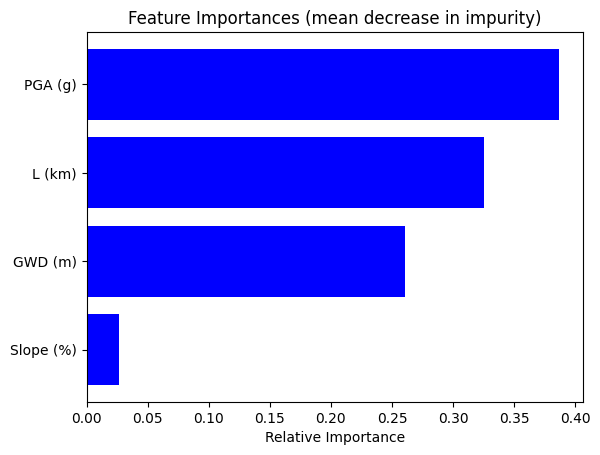

,feature,importance
3,PGA (g),0.386756
1,L (km),0.325500
0,GWD (m),0.260875
2,Slope (%),0.026869


In [37]:
# Display results for decision tree
plot_feature_importance(X_test, clf)

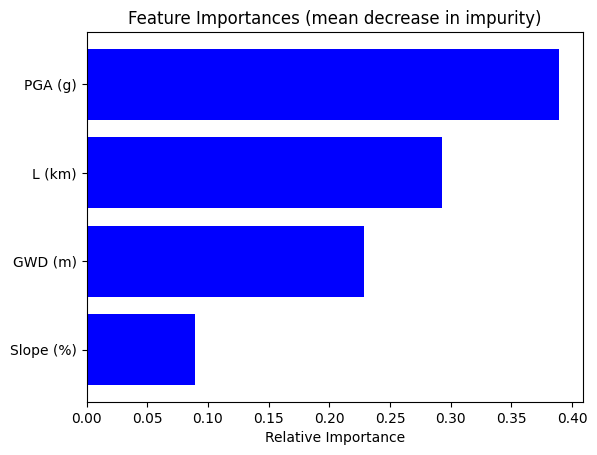

,feature,importance
3,PGA (g),0.389136
1,L (km),0.292835
0,GWD (m),0.228402
2,Slope (%),0.089627


In [38]:
# Display results for random forest
plot_feature_importance(X_test, rf)

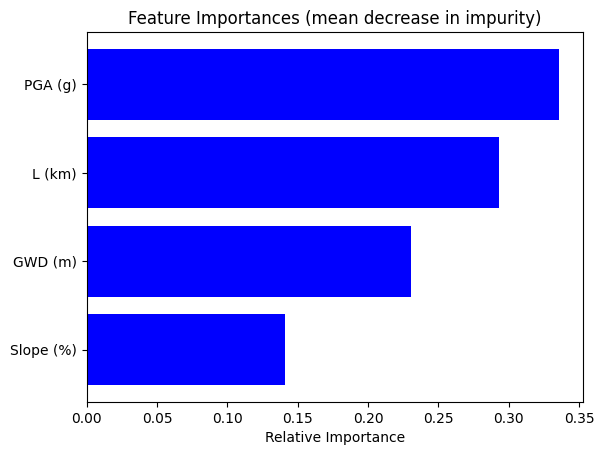

,feature,importance
3,PGA (g),0.335628
1,L (km),0.292887
0,GWD (m),0.230713
2,Slope (%),0.140771


In [39]:
# Display results for XGB
plot_feature_importance(X_test, xgb)

#### Permutation importance in code

`feature_importances_` is the mean decrease in impurity, measured on the training data while the
tree is built. It is biased toward continuous, high-cardinality features, and all four features
here are continuous. Permutation importance measures something different: how much test accuracy
falls when one column is shuffled. The two rankings need not agree.

In [40]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                              random_state=42, n_jobs=-1)

comparison = pd.DataFrame({
    'feature': X_test.columns,
    'impurity (train)': rf.feature_importances_,
    'permutation (test)': perm.importances_mean,
    'permutation std': perm.importances_std,
}).sort_values('permutation (test)', ascending=False)

print("Random forest: impurity importance against permutation importance")
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Random forest: impurity importance against permutation importance
  feature  impurity (train)  permutation (test)  permutation std
  PGA (g)            0.3891              0.2088           0.0185
   L (km)            0.2928              0.1694           0.0107
  GWD (m)            0.2284              0.1019           0.0084
Slope (%)            0.0896              0.0118           0.0028


### 3. Shapley Values (SHAP)

SHAP values are based on cooperative game theory and provide a unified measure of feature importance. They give the average contribution of a feature value to every possible prediction.

For a model with $M$ features, the Shapley value for feature $ i $ is computed as:

$$ \phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(M - |S| - 1)!}{M!} [v(S \cup \{i\}) - v(S)] $$

Where:
- $ S $ is a subset of features excluding feature $ i $
- $ N $ is the set of all features
- $ v(S) $ is the value function that gives the prediction for subset $ S $

**Note:** we explain the **Random Forest** below, not the XGBoost model. `shap.TreeExplainer`
handles both, so this is a choice, not a limitation: the random forest is the model the grid
search produced and saved to disk above. XGBoost is the more accurate model on this test set, so
remember that these explanations describe the weaker of the two.


### Understanding SHAP Values: An Analogy

SHAP values help us understand how different features (or variables) contribute to a prediction in a machine learning model. To explain this without mathematics, let's use an analogy of three team members working together on a project. Imagine that the team members are Alice, Bob, and Charlie, and we want to know how much each one contributed to the project's success.

#### The Project

The project's success is measured by the total output, and we want to fairly distribute the credit for this success among Alice, Bob, and Charlie.

#### Shapley Value Concept

Imagine breaking down the project into smaller tasks and observing how much the output changes when each team member is added or removed. The goal is to find the average contribution of each member over all possible ways the team could have been formed.

##### Step by Step Explanation

1. **No Team Members:** First, we measure the output with no team members working (a baseline).
2. **Adding One Member:** Then, we add each team member one by one and measure how much the output changes.
   - With Alice alone
   - With Bob alone
   - With Charlie alone
3. **Adding Two Members:** Next, we measure the change in output with pairs of team members:
   - Alice and Bob
   - Alice and Charlie
   - Bob and Charlie
4. **All Three Members:** Finally, we measure the output with all three working together.

#### Calculating Contributions

By comparing all these different combinations, we can calculate the average contribution of each team member. The SHAP value for each person is their fair share of the contribution to the project's success.

- **Alice's SHAP Value:** The average change in output when Alice is part of the team.
- **Bob's SHAP Value:** The average change in output when Bob is part of the team.
- **Charlie's SHAP Value:** The average change in output when Charlie is part of the team.

![Shapley](https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/figs/shap.png)

In [41]:
import shap
import numpy as np

# Explain the random forest saved above
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# pick one clearly predicted site of each class, so the waterfall matches its heading
proba = rf.predict_proba(X_test)[:, 1]
spreading_pos = int(np.argmax(np.where(y_test.values == 1, proba, -1.0)))
no_spreading_pos = int(np.argmin(np.where(y_test.values == 0, proba, 2.0)))

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Spreading example: test position {spreading_pos}, "
      f"P(spreading) = {proba[spreading_pos]:.2f}")
print(f"No-spreading example: test position {no_spreading_pos}, "
      f"P(spreading) = {proba[no_spreading_pos]:.2f}")

SHAP values shape: (729, 4, 2)
Spreading example: test position 86, P(spreading) = 0.99
No-spreading example: test position 144, P(spreading) = 0.02


In [42]:
X_test_target.head()

,GWD (m),L (km),Slope (%),PGA (g),Target
2271,1.818539,1.766037,0.355453,0.398704,1
125,2.118738,0.399891,0.183683,0.434206,1
1935,2.210156,1.468325,1.075267,0.397815,0
4987,2.442713,1.164817,0.566125,0.408304,0
4503,1.535410,2.125216,0.671203,0.385182,0


SHAP values are a measure used to explain the output of machine learning models. They tell us how much each feature in the model contributes to a particular prediction, compared to a baseline prediction.

#### Positive vs. Negative SHAP Values

- **Positive SHAP Values:** When a feature has a positive SHAP value, it means that the presence (or value) of that feature pushes the model's output higher than the baseline.
  - **Example:** In our lateral spreading prediction the PGA (a feature) gives a positive SHAP value, it means that higher PGA are generally associated with higher chance of lateral spreading.

- **Negative SHAP Values:** Conversely, when a feature has a negative SHAP value, it means that the presence (or value) of that feature pushes the model's output lower than the baseline.
  - **Example:** Still considering lateral spreading, a deep water table (large GWD) gives a negative SHAP value, which says the model predicts less chance of lateral spreading at such sites.


The term $E(f(x))$ represents the expected value or average prediction of the model over the entire dataset. Think of it as the "baseline prediction." When you see $E(f(x))$ , it's referring to what the model would predict on average, without considering any specific feature values.

- **Example:** here $E(f(x))$ is the average chance of lateral spreading the model predicts when it does not consider any specific features of a site. It is the starting point, before we account for a shallow water table or a high PGA.

#### Positive prediction (Spreading site)

In this example, we show a site that is predicted to have positive lateral spreading (failure) using the **Random Forest** model. The SHAP waterfall plot shows how each feature contributes to pushing the prediction away from the base value toward spreading.

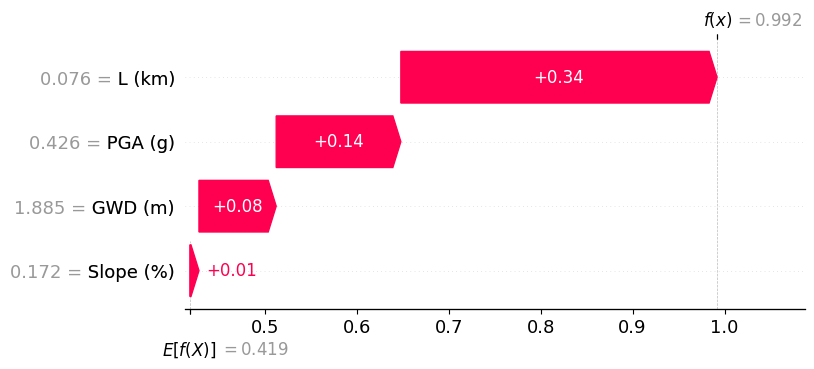

In [43]:
shap.plots.waterfall(shap_values[spreading_pos, :, 1])

#### Negative prediction (No spreading site)

In this example, we show the **Random Forest** model predicting a site that has no chance of lateral spreading. The SHAP waterfall plot helps us understand which features contribute most to this prediction.

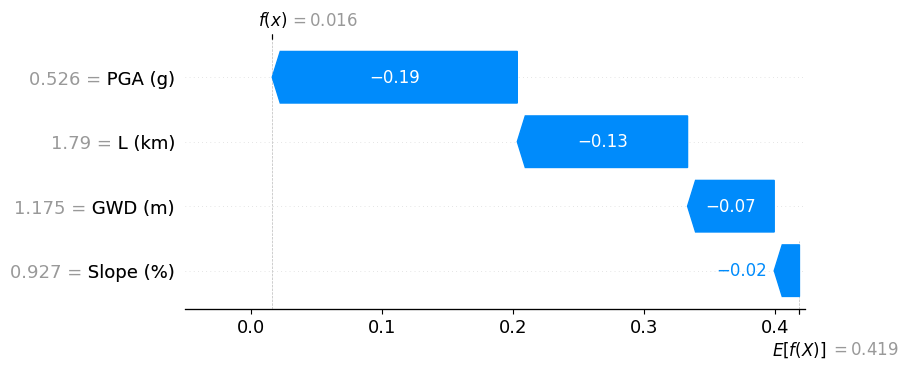

In [44]:
shap.plots.waterfall(shap_values[no_spreading_pos, :, 1])

### Global explanation

We observe global SHAP values from the **Random Forest** model to see how different features influence lateral spreading predictions across all test samples. 

**How to read the beeswarm plot:**
- **X-axis:** SHAP value (contribution to prediction)
- **Color:** Feature value (red = high, blue = low)
- **Each dot:** One test sample

**Key insights:**
- **L (distance to river):** Blue points (short distance) on the right → increases spreading risk
- **GWD (ground water depth):** Blue points (shallow water) on the right → increases spreading risk  
- **PGA (peak ground acceleration):** Higher PGA generally increases spreading risk
- **Slope:** Mixed effects depending on other features

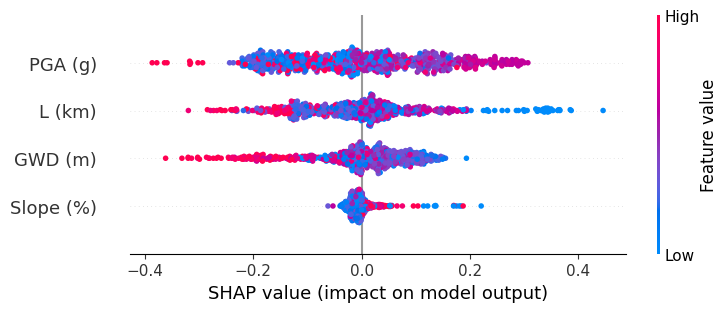

In [45]:
shap.plots.beeswarm(shap_values[:,:,1])

### SHAP Dependence Plots

Dependence plots show how a single feature affects predictions across its entire range of values, while also showing interaction effects with other features through color coding.

**How to read dependence plots:**
- **X-axis:** Value of the main feature being analyzed
- **Y-axis:** SHAP value (impact on prediction)
- **Color:** Value of the interacting feature
- **Scatter:** Each point represents one test sample

We'll focus on **PGA (Peak Ground Acceleration)** and its interactions with other features to understand:
1. How PGA alone affects lateral spreading predictions
2. How PGA's effect changes depending on other site conditions

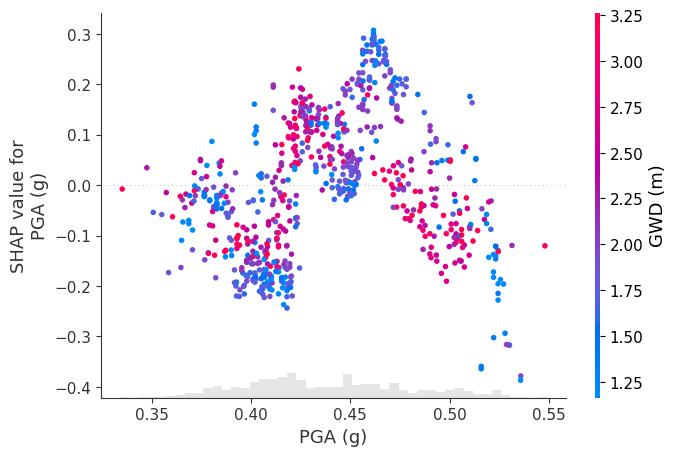

In [46]:
# PGA vs GWD (Ground Water Depth) interaction
shap.plots.scatter(shap_values[:, "PGA (g)", 1],
                   color=shap_values[:, "GWD (m)", 1])

#### Interpretation: PGA vs Distance to Water

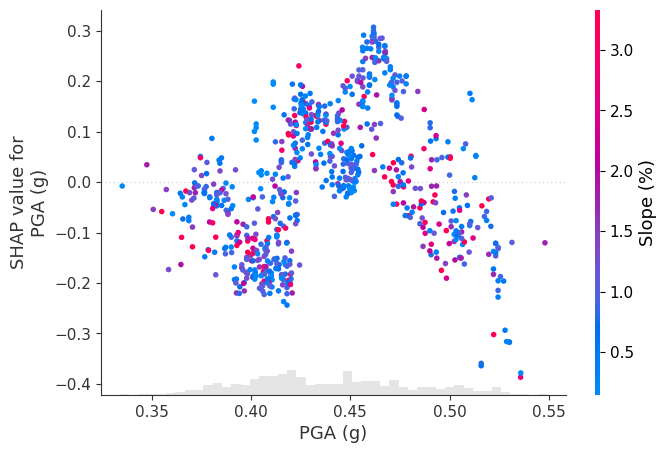

In [47]:
# PGA vs Slope interaction
shap.plots.scatter(shap_values[:, "PGA (g)", 1],
                   color=shap_values[:, "Slope (%)", 1])

### Analyzing Incorrect Predictions with SHAP

Now let's examine where the model makes mistakes, particularly at different PGA levels. This helps us understand:
1. **Model limitations** - When does the model fail?
2. **Feature interactions in failures** - What combinations confuse the model?
3. **PGA-specific errors** - Does the model struggle more at high or low PGA values?

In [48]:
# Get predictions from Random Forest model
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

# Identify incorrect predictions
incorrect_mask = (y_pred_rf != y_test)
correct_mask = (y_pred_rf == y_test)

# Create analysis dataframe
analysis_df = X_test.copy()
analysis_df['True_Label'] = y_test.values
analysis_df['Predicted'] = y_pred_rf
analysis_df['Prob_Spreading'] = y_proba_rf[:, 1]
analysis_df['Correct'] = correct_mask

# Categorize by PGA levels
analysis_df['PGA_Category'] = pd.cut(
    analysis_df['PGA (g)'], 
    bins=[0, 0.4, 0.5, 1.0],
    labels=['Low PGA (<0.4g)', 'Medium PGA (0.4-0.5g)', 'High PGA (>0.5g)']
)

print("Overall Model Performance:")
print(f"  Total test samples: {len(y_test)}")
print(f"  Correct predictions: {correct_mask.sum()} ({correct_mask.sum()/len(y_test)*100:.2f}%)")
print(f"  Incorrect predictions: {incorrect_mask.sum()} ({incorrect_mask.sum()/len(y_test)*100:.2f}%)")

print("\n" + "="*60)
print("Error Analysis by PGA Category:")
print("="*60)

for pga_cat in ['Low PGA (<0.4g)', 'Medium PGA (0.4-0.5g)', 'High PGA (>0.5g)']:
    mask = analysis_df['PGA_Category'] == pga_cat
    total = mask.sum()
    incorrect = (mask & ~analysis_df['Correct']).sum()
    
    print(f"\n{pga_cat}:")
    print(f"  Total samples: {total}")
    rate = incorrect / total * 100 if total > 0 else float("nan")
    print(f"  Incorrect: {incorrect} ({rate:.2f}% error rate)")
    
    # False Positives and False Negatives
    fp = ((analysis_df['True_Label'] == 0) & (analysis_df['Predicted'] == 1) & mask).sum()
    fn = ((analysis_df['True_Label'] == 1) & (analysis_df['Predicted'] == 0) & mask).sum()
    print(f"  False Positives (predicted spreading, but no spreading): {fp}")
    print(f"  False Negatives (predicted no spreading, but spreading occurred): {fn}")

Overall Model Performance:
  Total test samples: 729
  Correct predictions: 589 (80.80%)
  Incorrect predictions: 140 (19.20%)

Error Analysis by PGA Category:

Low PGA (<0.4g):
  Total samples: 125
  Incorrect: 24 (19.20% error rate)
  False Positives (predicted spreading, but no spreading): 1
  False Negatives (predicted no spreading, but spreading occurred): 23

Medium PGA (0.4-0.5g):
  Total samples: 528
  Incorrect: 104 (19.70% error rate)
  False Positives (predicted spreading, but no spreading): 33
  False Negatives (predicted no spreading, but spreading occurred): 71

High PGA (>0.5g):
  Total samples: 76
  Incorrect: 12 (15.79% error rate)
  False Positives (predicted spreading, but no spreading): 4
  False Negatives (predicted no spreading, but spreading occurred): 8


#### Visualizing Incorrect Predictions by PGA

Let's visualize where the model makes mistakes across different PGA values:

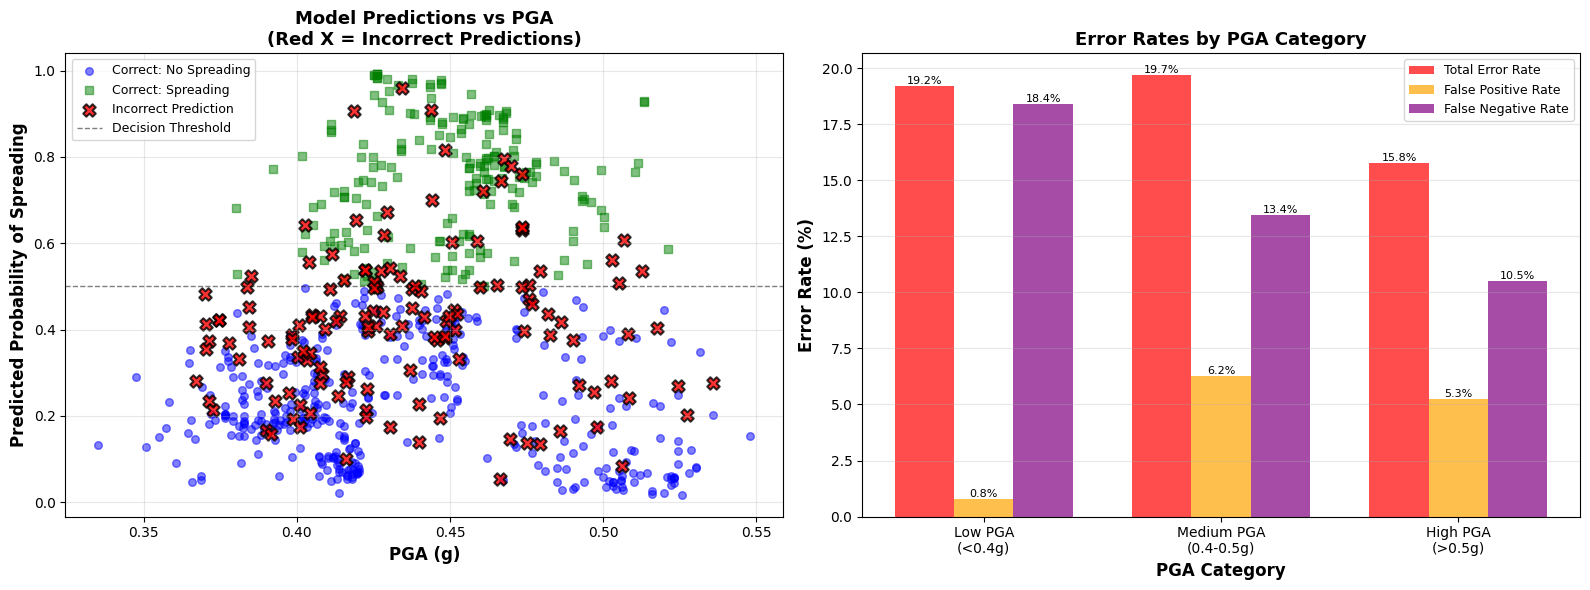

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter plot of PGA vs Prediction Probability
ax1 = axes[0]
correct_no_spread = analysis_df[(analysis_df['Correct']) & (analysis_df['True_Label'] == 0)]
correct_spread = analysis_df[(analysis_df['Correct']) & (analysis_df['True_Label'] == 1)]
incorrect_samples = analysis_df[~analysis_df['Correct']]

ax1.scatter(correct_no_spread['PGA (g)'], correct_no_spread['Prob_Spreading'], 
           alpha=0.5, s=30, c='blue', label='Correct: No Spreading', marker='o')
ax1.scatter(correct_spread['PGA (g)'], correct_spread['Prob_Spreading'], 
           alpha=0.5, s=30, c='green', label='Correct: Spreading', marker='s')
ax1.scatter(incorrect_samples['PGA (g)'], incorrect_samples['Prob_Spreading'], 
           alpha=0.8, s=80, c='red', edgecolors='black', linewidths=1.5,
           label='Incorrect Prediction', marker='X')

ax1.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Decision Threshold')
ax1.set_xlabel('PGA (g)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Probability of Spreading', fontsize=12, fontweight='bold')
ax1.set_title('Model Predictions vs PGA\n(Red X = Incorrect Predictions)', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Error rate by PGA category
ax2 = axes[1]
pga_categories = ['Low PGA\n(<0.4g)', 'Medium PGA\n(0.4-0.5g)', 'High PGA\n(>0.5g)']
error_rates = []
fp_rates = []
fn_rates = []

for pga_cat in ['Low PGA (<0.4g)', 'Medium PGA (0.4-0.5g)', 'High PGA (>0.5g)']:
    mask = analysis_df['PGA_Category'] == pga_cat
    total = mask.sum()
    incorrect = (mask & ~analysis_df['Correct']).sum()
    fp = ((analysis_df['True_Label'] == 0) & (analysis_df['Predicted'] == 1) & mask).sum()
    fn = ((analysis_df['True_Label'] == 1) & (analysis_df['Predicted'] == 0) & mask).sum()
    
    error_rates.append(incorrect/total*100 if total > 0 else 0)
    fp_rates.append(fp/total*100 if total > 0 else 0)
    fn_rates.append(fn/total*100 if total > 0 else 0)

x = range(len(pga_categories))
width = 0.25

bars1 = ax2.bar([i - width for i in x], error_rates, width, label='Total Error Rate', color='red', alpha=0.7)
bars2 = ax2.bar(x, fp_rates, width, label='False Positive Rate', color='orange', alpha=0.7)
bars3 = ax2.bar([i + width for i in x], fn_rates, width, label='False Negative Rate', color='purple', alpha=0.7)

ax2.set_xlabel('PGA Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Error Rates by PGA Category', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pga_categories)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### SHAP Analysis of Incorrect Predictions

Now let's use SHAP to understand WHY the model makes these mistakes. We'll compare SHAP values for incorrect predictions at high vs low PGA:

In [50]:
# Find indices of incorrect predictions in different PGA ranges
incorrect_indices = analysis_df[~analysis_df['Correct']].index

# Get original positions in X_test
X_test_reset = X_test.reset_index(drop=True)
incorrect_positions = []
for idx in incorrect_indices:
    pos = X_test.index.get_loc(idx)
    incorrect_positions.append(pos)

# Separate by PGA level
low_pga_incorrect = []
high_pga_incorrect = []

for pos in incorrect_positions:
    pga_value = X_test.iloc[pos]['PGA (g)']
    if pga_value < 0.4:
        low_pga_incorrect.append(pos)
    elif pga_value > 0.5:
        high_pga_incorrect.append(pos)

print(f"Found {len(low_pga_incorrect)} incorrect predictions at LOW PGA (<0.4g)")
print(f"Found {len(high_pga_incorrect)} incorrect predictions at HIGH PGA (>0.5g)")

# Show examples if available
if len(low_pga_incorrect) > 0:
    print(f"\nExample LOW PGA incorrect prediction:")
    idx_low = low_pga_incorrect[0]
    print(f"  Features: {X_test.iloc[idx_low].to_dict()}")
    print(f"  True label: {y_test.iloc[idx_low]}")
    print(f"  Predicted: {y_pred_rf[idx_low]}")
    print(f"  Predicted probability: {y_proba_rf[idx_low, 1]:.3f}")

if len(high_pga_incorrect) > 0:
    print(f"\nExample HIGH PGA incorrect prediction:")
    idx_high = high_pga_incorrect[0]
    print(f"  Features: {X_test.iloc[idx_high].to_dict()}")
    print(f"  True label: {y_test.iloc[idx_high]}")
    print(f"  Predicted: {y_pred_rf[idx_high]}")
    print(f"  Predicted probability: {y_proba_rf[idx_high, 1]:.3f}")

Found 24 incorrect predictions at LOW PGA (<0.4g)
Found 12 incorrect predictions at HIGH PGA (>0.5g)

Example LOW PGA incorrect prediction:
  Features: {'GWD (m)': 1.818539262, 'L (km)': 1.766037334, 'Slope (%)': 0.355453134, 'PGA (g)': 0.398704052}
  True label: 1
  Predicted: 0
  Predicted probability: 0.194

Example HIGH PGA incorrect prediction:
  Features: {'GWD (m)': 1.582697749, 'L (km)': 0.204464134, 'Slope (%)': 0.477317244, 'PGA (g)': 0.50500536}
  True label: 0
  Predicted: 1
  Predicted probability: 0.508


#### SHAP Waterfall Plots for Incorrect Predictions

Let's visualize SHAP explanations for specific incorrect predictions to understand what features led the model astray:

LOW PGA Incorrect Prediction - SHAP Analysis

Features: PGA=0.399g, GWD=1.82m, L=1.77km, Slope=0.36%
True: Spreading, Predicted: No Spreading
Probability of spreading: 0.194



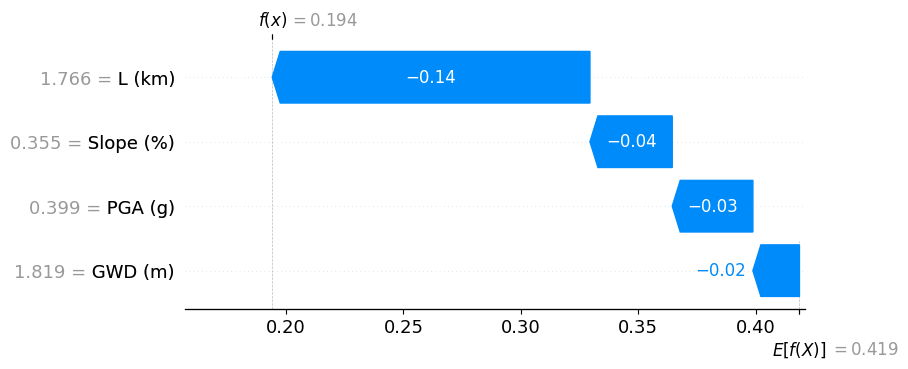


HIGH PGA Incorrect Prediction - SHAP Analysis

Features: PGA=0.505g, GWD=1.58m, L=0.20km, Slope=0.48%
True: No Spreading, Predicted: Spreading
Probability of spreading: 0.508



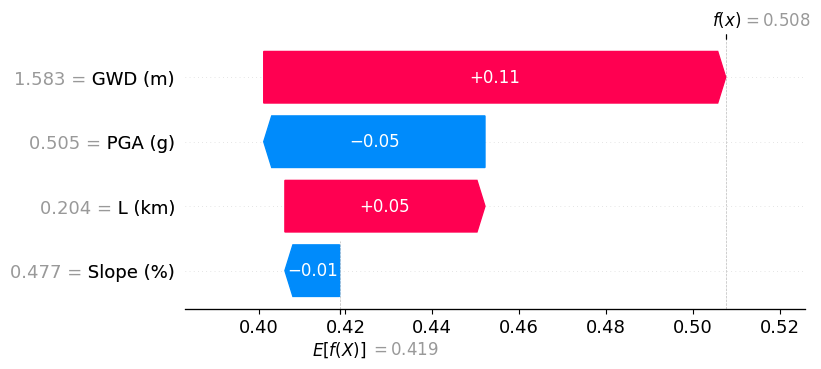

In [51]:
# Show SHAP waterfall plots for incorrect predictions at LOW and HIGH PGA
if len(low_pga_incorrect) > 0:
    print("="*60)
    print("LOW PGA Incorrect Prediction - SHAP Analysis")
    print("="*60)
    idx = low_pga_incorrect[0]
    print(f"\nFeatures: PGA={X_test.iloc[idx]['PGA (g)']:.3f}g, "
          f"GWD={X_test.iloc[idx]['GWD (m)']:.2f}m, "
          f"L={X_test.iloc[idx]['L (km)']:.2f}km, "
          f"Slope={X_test.iloc[idx]['Slope (%)']:.2f}%")
    print(f"True: {'Spreading' if y_test.iloc[idx]==1 else 'No Spreading'}, "
          f"Predicted: {'Spreading' if y_pred_rf[idx]==1 else 'No Spreading'}")
    print(f"Probability of spreading: {y_proba_rf[idx, 1]:.3f}\n")
    shap.plots.waterfall(shap_values[idx, :, 1], show=True)

if len(high_pga_incorrect) > 0:
    print("\n" + "="*60)
    print("HIGH PGA Incorrect Prediction - SHAP Analysis")
    print("="*60)
    idx = high_pga_incorrect[0]
    print(f"\nFeatures: PGA={X_test.iloc[idx]['PGA (g)']:.3f}g, "
          f"GWD={X_test.iloc[idx]['GWD (m)']:.2f}m, "
          f"L={X_test.iloc[idx]['L (km)']:.2f}km, "
          f"Slope={X_test.iloc[idx]['Slope (%)']:.2f}%")
    print(f"True: {'Spreading' if y_test.iloc[idx]==1 else 'No Spreading'}, "
          f"Predicted: {'Spreading' if y_pred_rf[idx]==1 else 'No Spreading'}")
    print(f"Probability of spreading: {y_proba_rf[idx, 1]:.3f}\n")
    shap.plots.waterfall(shap_values[idx, :, 1], show=True)

#### Comparing SHAP Values: Correct vs Incorrect Predictions

Let's compare the distribution of SHAP values between correct and incorrect predictions to identify patterns in model failures:

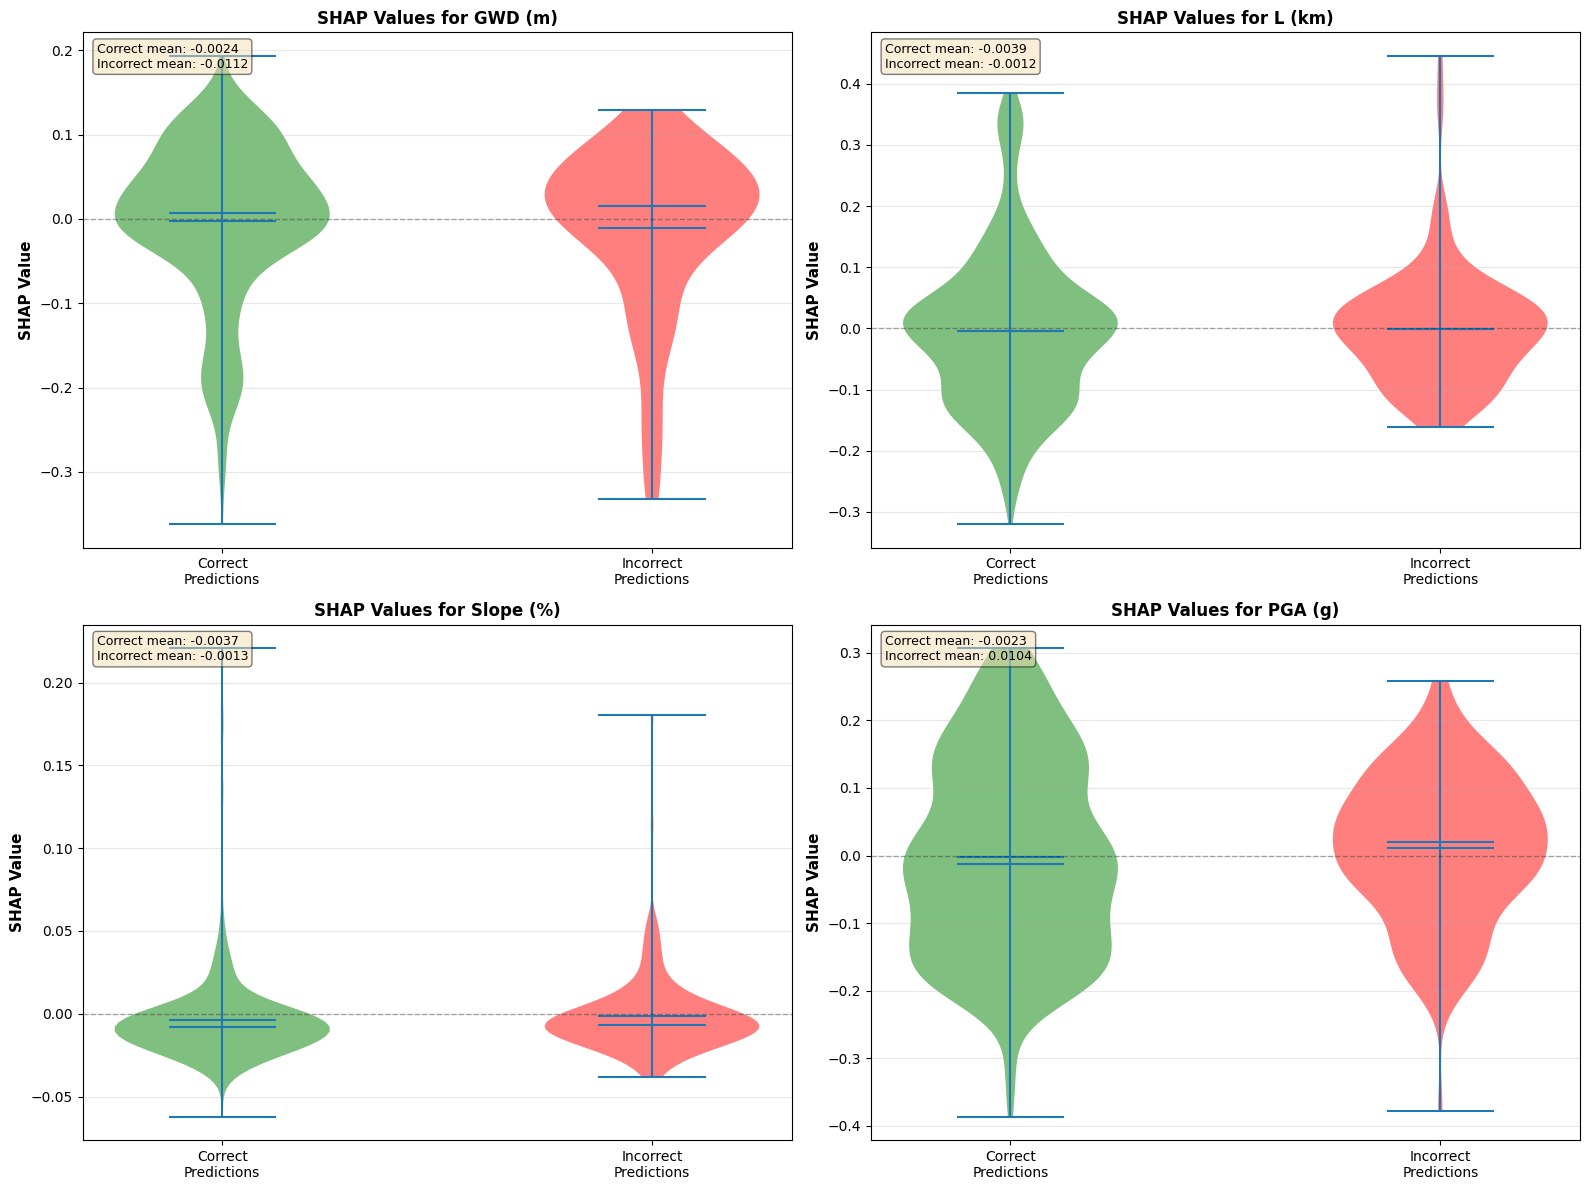


Summary: SHAP Value Comparison
GWD (m):
  Correct predictions mean SHAP:   -0.0024
  Incorrect predictions mean SHAP: -0.0112
  Difference:                      -0.0088

L (km):
  Correct predictions mean SHAP:   -0.0039
  Incorrect predictions mean SHAP: -0.0012
  Difference:                       0.0027

Slope (%):
  Correct predictions mean SHAP:   -0.0037
  Incorrect predictions mean SHAP: -0.0013
  Difference:                       0.0024

PGA (g):
  Correct predictions mean SHAP:   -0.0023
  Incorrect predictions mean SHAP:  0.0104
  Difference:                       0.0128



In [52]:
# Create comparison dataframe with SHAP values
feature_names = ['GWD (m)', 'L (km)', 'Slope (%)', 'PGA (g)']
shap_df = pd.DataFrame(
    shap_values[:, :, 1].values,
    columns=[f'SHAP_{feat}' for feat in feature_names]
)
shap_df['Correct'] = correct_mask.values
shap_df['PGA'] = X_test['PGA (g)'].values
shap_df['PGA_Category'] = analysis_df['PGA_Category'].values

# Plot SHAP value distributions for correct vs incorrect
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    ax = axes[i]
    shap_col = f'SHAP_{feat}'
    
    # Separate by correctness
    correct_shap = shap_df[shap_df['Correct']][shap_col]
    incorrect_shap = shap_df[~shap_df['Correct']][shap_col]
    
    # Create violin plots
    parts = ax.violinplot([correct_shap, incorrect_shap], 
                          positions=[1, 2],
                          showmeans=True, showmedians=True)
    
    # Color the violins
    for pc, color in zip(parts['bodies'], ['green', 'red']):
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Correct\nPredictions', 'Incorrect\nPredictions'])
    ax.set_ylabel(f'SHAP Value', fontsize=11, fontweight='bold')
    ax.set_title(f'SHAP Values for {feat}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
    
    # Add statistics
    correct_mean = correct_shap.mean()
    incorrect_mean = incorrect_shap.mean()
    ax.text(0.02, 0.98, f'Correct mean: {correct_mean:.4f}\nIncorrect mean: {incorrect_mean:.4f}',
           transform=ax.transAxes, fontsize=9, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nSummary: SHAP Value Comparison")
print("="*60)
for feat in feature_names:
    shap_col = f'SHAP_{feat}'
    correct_mean = shap_df[shap_df['Correct']][shap_col].mean()
    incorrect_mean = shap_df[~shap_df['Correct']][shap_col].mean()
    diff = incorrect_mean - correct_mean
    print(f"{feat}:")
    print(f"  Correct predictions mean SHAP:   {correct_mean:7.4f}")
    print(f"  Incorrect predictions mean SHAP: {incorrect_mean:7.4f}")
    print(f"  Difference:                      {diff:7.4f}")
    print()

### Key Insights from Incorrect Prediction Analysis

**What We Learned:**

1. **Error Distribution by PGA:**
   - The model's error rate varies across PGA levels
   - Visualizations show where predictions are most uncertain (near decision boundary at 0.5 probability)
   - Red X markers highlight specific failure cases

2. **SHAP Analysis Reveals Why Predictions Fail:**
   - **Low PGA failures:** Model may incorrectly predict spreading when other features (shallow water table, proximity to water) strongly suggest it, despite low earthquake intensity
   - **High PGA failures:** Model may miss spreading cases where protective factors (deep water table, distance from water) counteract high PGA
   
3. **Feature Contribution Differences:**
   - The violin plots show how SHAP values differ between correct and incorrect predictions
   - Features with larger mean SHAP differences between correct/incorrect cases indicate where the model struggles
   - This identifies which feature interactions confuse the model most

4. **Implications for Model Improvement:**
   - Cases near the decision boundary need attention
   - Complex feature interactions (especially involving PGA) may require:
     - More training data in problematic regions
     - Feature engineering to capture non-linear interactions better
     - Ensemble methods to reduce uncertainty
   
5. **Engineering Judgment:**
   - Some "incorrect" predictions may actually reflect real-world uncertainty
   - Sites with contradictory features (e.g., high PGA but deep water table) are inherently difficult to classify
   - The model's uncertainty (probability near 0.5) is valuable information for engineers